### Самый честный способ создания диффузионной задачи

Модели загружаются лениво: при первом `to(device)` или `run()`. Создание графа — мгновенно.

In [1]:
from yggdrasill import Hypergraph

graph = Hypergraph(name="MySD15Graph")

graph.add_node("MyAwesomeBackbone", type="sd15.unet", pretrained="runwayml/stable-diffusion-v1-5")
graph.add_node("MyAwesomeScheduler", type="sd15.scheduler", pretrained="runwayml/stable-diffusion-v1-5")
graph.add_node("MyAwesomeTokenizer", type="sd15.tokenizer", pretrained="runwayml/stable-diffusion-v1-5")
graph.add_node("MyAwesomeTextEncoder", type="sd15.text_encoder", pretrained="runwayml/stable-diffusion-v1-5")
graph.add_node("MyAwesomeAutoencoder", type="sd15.autoencoder", pretrained="runwayml/stable-diffusion-v1-5")

graph.to("cuda")

/workspace/YggDrasill/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 4260.27it/s]
CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/workspace/YggDrasill/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Generating: 100%|██████████| 51/51 [00:06<00:00,  7.57step/s]


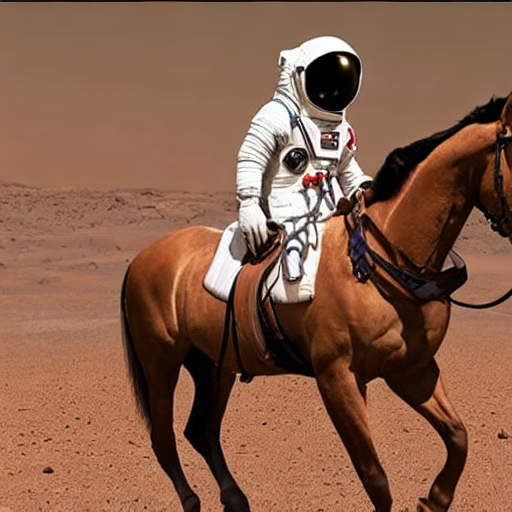

In [2]:
output = graph.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=512,
    height=512,
)

output.images[0]

### Использование в 2 строчки кода

Generating: 100%|██████████| 51/51 [00:06<00:00,  8.31step/s]


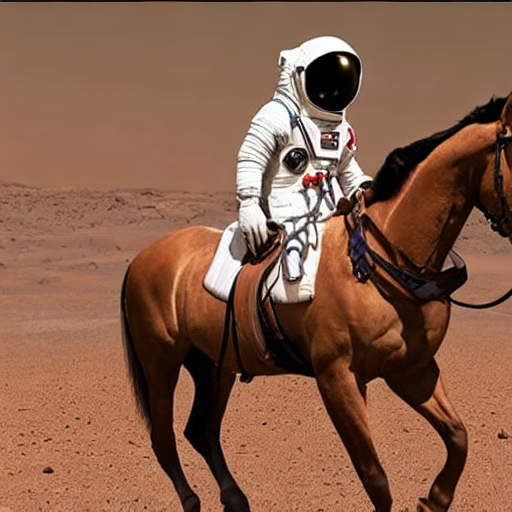

In [3]:
from yggdrasill import Hypergraph

graph = Hypergraph.from_template("sd15_text2image", device="cuda")

output = graph.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=512,
    height=512,
)

output.images[0]

Loading weights: 100%|██████████| 196/196 [00:00<00:00, 3982.83it/s]]
CLIPTextModel LOAD REPORT from: /workspace/.hf_home/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 396/396 [00:00<00:00, 2928.08it/s]2.75it/s]
StableDiffusionSafetyChecker LOAD REPORT from: /workspace/.hf_home/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can

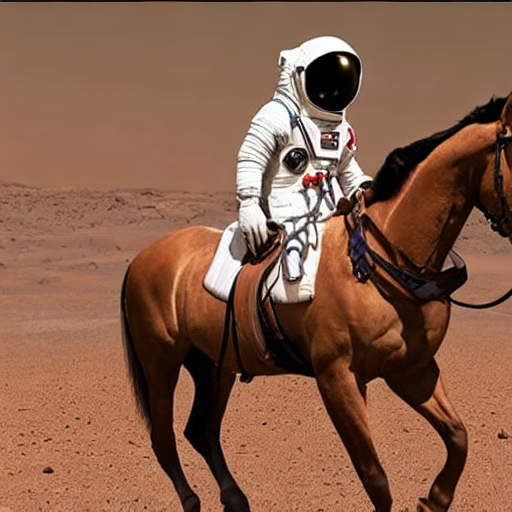

In [4]:
import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")

pipe.to("cuda")

output = pipe(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    generator=torch.Generator(device="cuda").manual_seed(42),
    width=512,
    height=512,
)

output.images[0]